In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# First let's find the exact file path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/copy-of-titanic21/train.csv
/kaggle/input/competitions/copy-of-titanic21/test.csv
/kaggle/input/competitions/copy-of-titanic21/gender_submission.csv


In [3]:
# Load the training data (using the correct path)
df = pd.read_csv('/kaggle/input/competitions/copy-of-titanic21/train.csv')

# See the shape (rows, columns)
print("Shape:", df.shape)

# See first 5 rows
df.head()



Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Overall survival rate: 0.38

Survival by gender:
Sex
female    0.74
male      0.19
Name: Survived, dtype: float64


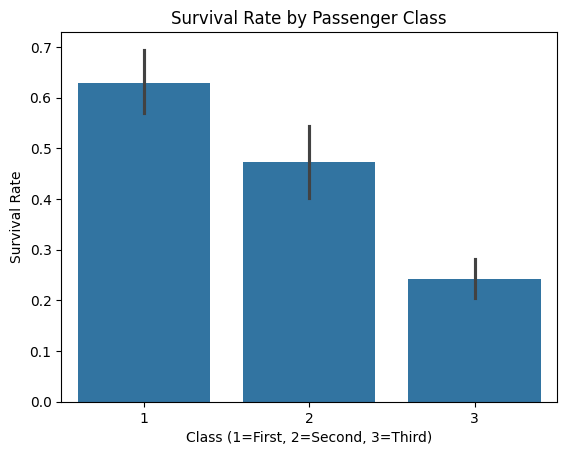

In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Survival rate overall
print("\nOverall survival rate:", df['Survived'].mean().round(2))

# Survival by gender
print("\nSurvival by gender:")
print(df.groupby('Sex')['Survived'].mean().round(2))

# Visualise survival by passenger class
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.show()

In [5]:
# Fill missing Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert Sex to numbers (ML needs numbers, not text)
# female = 0, male = 1
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Create a new feature: family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Select features for the model
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']
X = df[features]   # inputs
y = df['Survived'] # what we want to predict

print("Data cleaned!")
print("Features shape:", X.shape)
print("\nFirst 3 rows of features:")
print(X.head(3))

Data cleaned!
Features shape: (891, 6)

First 3 rows of features:
   Pclass  Sex   Age     Fare  Embarked  FamilySize
0       3    1  22.0   7.2500         0           2
1       1    0  38.0  71.2833         1           2
2       3    0  26.0   7.9250         0           1


In [6]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it! (This is the actual "machine learning" happening)
model.fit(X_train, y_train)

# Make predictions on test data
predictions = model.predict(X_test)

# See the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 81.01%

Detailed Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



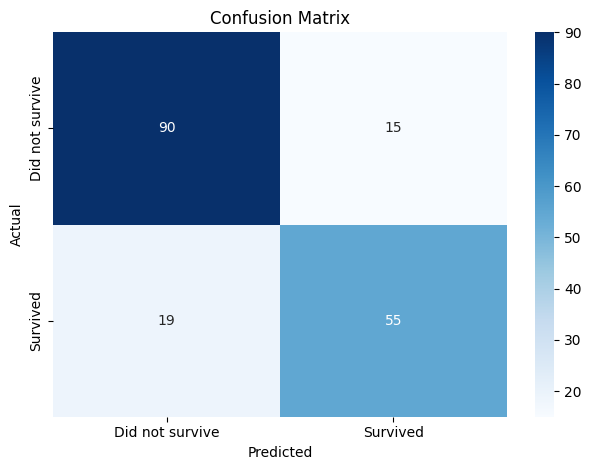

In [7]:
# Confusion Matrix - visual
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

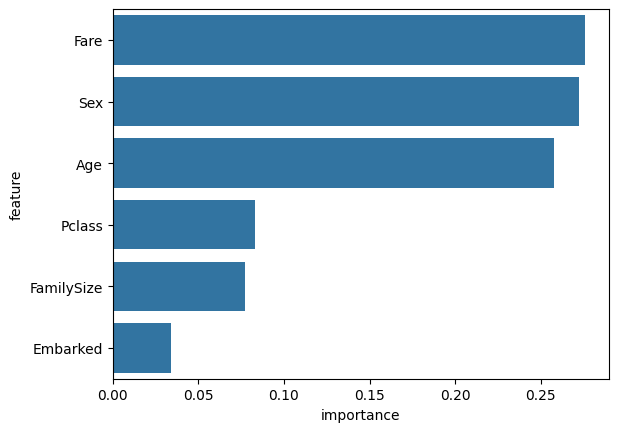

In [8]:
feat_imp = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
feat_imp = feat_imp.sort_values('importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.show()